# Cálculo numérico de propagadores mediante la integral de caminos de Feynman
Josué Cuauhtémoc Bucio Rivera

<script type="text/x-mathjax-config">
MathJax.Hub.Config({
  TeX: {
    Macros: {
      braket: ["\\langle #1 \\rangle", 1]
    }
  }
});
</script>
## Introducción

## Teoría

### Propagador
El propagador es la amplitud de probabilidad de que un sistema al tiempo $t_i$ y posición con eigenvalor $x_i$ se encuentre en $x_f$ al tiempo $t_f$. Cuya expresión es:
$$
\braket{x_f,t_f| x_i,t_i}
$$

### Cuantización por integral de caminos
Podemos expresar el propagador de la siguiente manera:
$$
\braket{x_f,t_f| x_i,t_i} = \int dx_{n-1} \int dx_{n-2} ... \int dx_1 \braket{x_f,t_f| x_{n-1},t_{n-1}} ... \braket{x_1,t_1| x_i,t_i} 
$$
En donde $t_f > t_n > ... > t_1 > t_i$. \
Adicionalmente, al cambiar al cuadro de Schrödinger:
$$
\braket{x_i,t_i | x_j,t_j} = \braket{x_i|exp \left( \frac{-i}{\hbar}(t_i - t_j )H \right)|x_j}
$$
Con esto se puede encontrar la siguiente expresión para el propagador:
$$
\braket{x_f,t_f| x_i,t_i} = \int_{x_i}^{x_f} \mathcal{D}[x(t)] \exp \left( \frac{i}{\hbar} \int_{x_i}^{x_f} dt \, L_{clásico}(x,\dot{x}) \right) 
$$
donde se define la medida funcional $\mathcal{D}[x(t)]$:
$$
\mathcal{D}[x(t)] = \lim_{(n, \epsilon) \to (\infty, 0)} \left( \frac{m}{2 \pi i \hbar \epsilon} \right)^{\frac{n}{2}} \int dx_{n-1} \int dx_{n-2} ... \int dx_1 
$$
La expresión:
$$
\int_{x_i}^{x_f} \mathcal{D}[x(t)] \exp \left( \frac{i}{\hbar} \int_{x_i}^{x_f} dt \, L_{clásico}(x,\dot{x}) \right) 
$$
es conocida como la integral de caminos de Feynman y es una manera de cuantizar (equivalente a la ecuación de Schrödinger) [1]. 

## Importancia del proyecto 
¿Por qué es importante la integral de caminos?\
Los campos, al tener un número infinito de grados de libertad, hacen que formular una ecuación de Schrödinger para campos conduzca a una ecuación diferencial funcional, lo cual es matemática y computacionalmente complejo. Otro punto clave es que la ecuación de Schrödinger no es relativista ya que trata al tiempo de forma absoluta.

Por otro lado, la integral de caminos se adapta naturalmente a una formulación covariante, es decir, invariante bajo transformaciones de Lorentz, lo que la hace ideal para teorías relativistas como la teoría cuántica de campos (QFT).

Ahora que se dejó en evidencia la importancia de la integral de caminos, ¿está justificado el cálculo numérico de las integrales de caminos? \
Sí, ya que existen muy pocos sistemas a los cuales les podemos calcular de manera analítica la integral de caminos, los únicos ejemplos son la partícula libre y los lagrangianos de a lo más grado dos. Por esto mismo en otros casos es necesario realizar este cálculo de manera numérica.

# Objetivos 
### Primario
-Cálculo numérico de propagadores en 1D para estimar energía.
### Secundarios
-Mostrar límites de la integración directa. \
-Uso del método de Monte Carlo.

# Calculando una integral de caminos numéricamente

Podemos hacer dos cosas:  
1. Integración directa  
2. Buscar una alternativa  

En este trabajo se hicieron ambas.  
Ya que el integrando es proporcional a $exp(-i F(x_i))$, entonces para tiempos largos su comportamiento oscilatorio es un problema.  

### Integración directa

Para calcular una integral de caminos numéricamente por integración directa aproximamos la acción con una suma de Riemann.

$$
S \approx \sum_{i=0}^{n-1} \left[ \frac{m}{2} \left( \frac{x_{i+1} - x_i}{\Delta t} \right)^2 - V \left( \frac{x_{i+1} + x_i}{2} \right) \right] \Delta t
$$

Ahora que la acción está discretizada podemos fijar un n  y aproximar la integral múltiple (n-1)-dimensional. \
Para el cálculo de la integral se hará uso de la función nquad de SciPy.
Esta función aproxima el valor de una integral n-dimensional mediante la suma de pesos ponderados sobre cada integral, es decir:
$$
\int d\vec x f(\vec x) \approx \prod_{i=1}^{n} \sum_{j_i} \omega_{j_i} f_{j_i}
$$
Los pesos ponderados están dados por la cuadratura de Gauss-Kronrod [2]. \
Usaremos unidades naturales $\hbar = 1$.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import integrate 
import math as m 
from scipy.stats import linregress

In [2]:
def prop_libre_id(x_i, x_f, T, m, N):
    """
    Calcula el propagador libre usando integración directa (ID)
    - x_i: posición inicial
    - x_f: posición final
    - T: tiempo total
    - m: masa de la partícula
    - N: número de intervalos de tiempo (=> N-1 puntos intermedios)
    """
    dt = T / N  # Paso temporal

    # Acción clásica discretizada
    def action(*x):
        # Se construye la trayectoria completa: [x_i, x1, x2, ..., x_{N-1}, x_f]
        path = [x_i] + list(x) + [x_f]
        S = 0.0
        for j in range(N):
            dx = path[j+1] - path[j]
            S += (dx**2) / dt
        S *= 0.5 * m
        return S

    #Parte real del integrando
    def integrand_re(*x):
        S = action(*x)
        return np.cos(S)

    #Parte imaginaria del integrando
    def integrand_im(*x):
        S = action(*x)
        return np.sin(S)

    # Rango de integración sobre las variables intermedias
    L = 20.0
    limits = [[-L, L]] * (N - 1)  # N-1 variables intermedias

    # Integración, se separo en parte real e imaginaria 
    result_re, _ = integrate.nquad(integrand_re, limits) 
    result_im, _ = integrate.nquad(integrand_im, limits)

    #Construimos el propagador sumando su parte real e imaginaria
    result = result_re + 1j * result_im

    # Factor de normalizacion
    prefactor = (m / (2 * np.pi * 1j * dt))**(N / 2)
    result *= prefactor

    return result

<script type="text/x-mathjax-config">
MathJax.Hub.Config({
  TeX: {
    Macros: {
      braket: ["\\langle #1 \\rangle", 1]
    }
  }
});
</script>
Para comparar, en este caso tenemos un expresión para el propagador libre
$$
\braket{x_f, t_f | t_i, x_i } = \left( \frac{m}{2 \pi i \Delta t} \right)^{\frac{1}{2}} exp\left( \frac{i}{2} \frac{(\Delta x)^2}{\Delta t} \right)
$$ 

In [3]:
def prop_libre_a(xi, xf, t, m):
    factor = (m/(2* np.pi * 1j * t))**.5
    fac_exp = np.exp(0.5j*((xf-xi)**2)/t)
    return factor*fac_exp

In [4]:
print('|_____Analitico_____|______Numerico______|__X_f_|__T_f__|ERP(Re)_|__ERP(Im)_')
for N in range(2, 5): #Numero de variables intermedias 
    print('N = ', N)
    for i in range(10, 14): # Eigenvalor de posicion final a usar
        a = float(i)
        
        pa = prop_libre_a(0.0, a, a**2, 1.0) # pa : propagador analtico 
        
        pid = prop_libre_id(0.0, a, a**2, 1.0, N) # pid: propagador de integracion directa
    
        c = round(abs((pa.real - pid.real)/pa.real)*100,3) #Error relativo porcentual parte real 
        d = round(abs((pid.imag - pa.imag)/pa.imag)*100,3) #Error relativo porcenutal parte imaginaria
        
        print(f' {round(pa.real, 4)} + i {round(pa.imag, 4)} | {round(pid.real, 4)}  + i {round(pid.imag, 4)}| {a} | {a**2} | {c} | {d}')

|_____Analitico_____|______Numerico______|__X_f_|__T_f__|ERP(Re)_|__ERP(Im)_
N =  2
 0.0383 + i -0.0112 | 0.0344  + i -0.0074| 10.0 | 100.0 | 10.169 | 34.472
 0.0348 + i -0.0102 | 0.0382  + i -0.0037| 11.0 | 121.0 | 9.711 | 63.551
 0.0319 + i -0.0094 | 0.0401  + i -0.0085| 12.0 | 144.0 | 25.621 | 9.046
 0.0294 + i -0.0086 | 0.0361  + i -0.0139| 13.0 | 169.0 | 22.636 | 60.522
N =  3
 0.0383 + i -0.0112 | 0.035  + i -0.0041| 10.0 | 100.0 | 8.507 | 63.42
 0.0348 + i -0.0102 | 0.0405  + i -0.0055| 11.0 | 121.0 | 16.376 | 46.12
 0.0319 + i -0.0094 | 0.0388  + i -0.0099| 12.0 | 144.0 | 21.551 | 6.226
 0.0294 + i -0.0086 | 0.0357  + i -0.0133| 13.0 | 169.0 | 21.214 | 54.475
N =  4
 0.0383 + i -0.0112 | 0.0377  + i -0.0112| 10.0 | 100.0 | 1.501 | 0.542
 0.0348 + i -0.0102 | 0.0369  + i -0.0004| 11.0 | 121.0 | 6.044 | 96.468
 0.0319 + i -0.0094 | 0.0473  + i -0.0084| 12.0 | 144.0 | 48.29 | 10.231
 0.0294 + i -0.0086 | 0.0393  + i -0.0219| 13.0 | 169.0 | 33.484 | 153.11


Incluso haciendo simplificaciones muy grandes, como tomar N = 4 cuando N en realidad tiende a infinito, o tomar el intervalo de integración sobre las variables de -20 a 20 cuando debería ser de menos infinito a infinito, el tiempo de compilación promedio es de 42.5 s en uno de los mejores casos. Y el punto decisivo es que la diferencia de tiempos no puede ser menor a 8 en el mejor por lo que el cálculo de energías no es posible. Lo mejor será buscar una alternativa. 

<script type="text/x-mathjax-config">
MathJax.Hub.Config({
  TeX: {
    Macros: {
      braket: ["\\langle #1 \\rangle", 1]
    }
  }
});
</script>
## Métodos de Monte-Carlo  
Un método de Monte Carlo es una técnica numérica para resolver un problema de carácter determinista mediante la introducción de un componente aleatorio [3].  

### Ley de los grandes números  
Sea ${ (X_i)}_{i=1}^N $ un conjunto de variables aleatorias, independientes e idénticamente distribuidas con valor esperado $\mathbb{E}[X_i] = \mu < \infty$, entonces  

$$  
P\left(\lim_{N \to \infty} \frac{1}{N} \sum_{i=1}^{N} X_i = \mu\right) = 1  
$$  

A partir de ese resultado se puede probar el siguiente [4].

### Integración de Monte Carlo  
Si ${ (X_i)}_{i=1}^N $ son un conjunto de variables aleatorias, independientes e idénticamente distribuidas, entonces para una función $g(\mathbb{X})$ se cumple  

$$  
G_N = \frac{1}{N} \sum_{i=1}^{N} g(X_i)  
$$  

$$  
G_N \approx \int g(\mathbb{X}) \, d\mathbb{X}  
$$  
[4]\
Para aplicar lo anterior al problema de calcular un propagador se tiene que hacer un "truco" primero. 

## Rotación de Wick  
La rotación de Wick consiste en hacer una transformación en el tiempo de la siguiente manera:  

$$  
t \to -i \tau  
$$  

donde $\tau \in \mathbb{R}$.  
[5]. \
Esta rotación nos permite tratar al integrando como una función en la que se puede usar una integración de Monte Carlo. Para esta función rotada, el integrando se asemeja a una distribución de Boltzmann entonces cumple la ley de los grandes números, mientras que si intentáramos usar este método sin aplicar Wick, tendríamos problemas con la cancelación de términos por las funciones oscilatorias. 

## ¿Y para qué sirven los tiempos imaginarios?

Para aproximar energías, por ejemplo, cuando se cumple que

$$
\exp(- E_0 \tau_i) \gg \exp(-E_1 \tau_f)
$$

entonces puedes aproximar $ E_0 $  usando que

$$
\log \braket{x, \tau_f \mid x, \tau_i} \approx -E_0 \tau + \text{cte}
$$

También sirve para encontrar la función de correlación en mecánica estadística, pero ese problema no se tratará aquí [5][6].


## Aproximación con la rotación de Wick  
Sigue siendo lo mismo que anteriormente, solo que ahora tomamos la aproximación de Monte Carlo y el tiempo imaginario. El exponente de $e$ se transforma en  

$$  
S \approx - \sum_{i=0}^{n-1} \left[ \frac{m}{2} \left( \frac{x_{i+1} - x_i}{\Delta \tau} \right)^2 + V(x_i) \right] \Delta \tau  
$$  

(Nótese que no hay números imaginarios)  

Por lo que  

$$  
\braket{x_f,t_f| x_i,t_i} \approx \int dx_1 \ldots dx_{n-1} \exp\left(- \sum_{i=0}^{n-1} \left[ \frac{m}{2} \left( \frac{x_{i+1} - x_i}{\Delta \tau} \right)^2 + V(x_i) \right] \Delta \tau \right)  
$$  

$$  
\approx \frac{1}{M} \sum_{j=0}^{M} \exp\left(- \sum_{i=0}^{n-1} \left[ \frac{m}{2} \left( \frac{y_{i+1}^j - y_i^j}{\Delta \tau} \right)^2 + V(y_i^j ) \right] \Delta \tau \right)  
$$  

En donde $n-1$ es el número de variables y $M$ es el número de trayectorias aleatorias, independientes e idénticamente distribuidas. \

Pero esta alternativa, como está, no termina de funcionar, ya que las trayectorias aleatorias tienen que ser infinitas para que el método funcione correctamente. Por lo tanto, hay que buscar una manera en la que las trayectorias finitas que nosotros construyamos sean significativas. A uno de esos métodos se le llama método de Monte Carlo por cadenas de Markov.

## Cadena de Markov

Sea $ \{X_i\}_{i=1}^N $ un conjunto de variables aleatorias que representan el estado de un sistema en un tiempo $n$, con $n \in \{1, ..., N\}$. La probabilidad de pasar del estado $i$ en el tiempo $n$ al estado $j$ en el tiempo $n+1$ es

$$
P_{ij} = P\{X_{n+1} = j \mid X_n = i\}
$$

y es independiente de los estados anteriores a $i$. Al conjunto $ \{X_i\}_{i=1}^N $ se le llama una cadena de Markov  [4].

## Algoritmo MCMC (Metropolis)

Sea una trayectoria aleatoria $ \{X_i\}_{i=1}^N $ (irreducible, aperiódica y recurrente positiva) que cumplen la ley de los grandes números para una distribución de probabilidad $f(X)$. Si $T(X \mid Y)$ es la densidad de probabilidad de transición para un movimiento de prueba de $Y$ a $X$ (normalizada), entonces la probabilidad de aceptación es:

$$
A(X \mid Y) = \min\left(1, \frac{T(Y \mid X) f(X)}{T(X \mid Y) f(Y)} \right)
$$

Ahora se genera un número aleatorio $u \in [0, 1)$ y:

$$
\text{si } u < A, \quad \text{entonces se acepta } X
$$

$$
\text{si } u > A, \quad \text{entonces te quedas en } Y
$$
[4]. \
Este método nos permite asegurar una convergencia más rápida, es decir, no tendremos que usar una cantidad absurdamente grande de muestras para obtener una buena aproximación. \
Aquí se usará $X = Y + \delta Y$.


In [5]:
def accion(path, dtau, potencial, m): #Aproximacion numerica de la accion 
    a = np.diff(path)**2
    int_K = 0.5*m*np.sum(a)/dtau   #Aproximacion de la integral de la energia cinetica
    int_potencial = np.sum([potencial(punto, m) for punto in path[:-1]])*dtau  #Aproximacion de la integral del potencial

    return int_potencial + int_K

In [6]:
def metropolis(xi, xf, n, pasos_m, m, delta, potencial, dtau):
    path = np.linspace(xi, xf, n+1)

    for _ in range(pasos_m):
        i = np.random.randint(1, n)  #Elige un numero aleatorio entre 1 y n
        
        y = path[i]   #Que sea i y no el numero en el rango del for hace mas estocastico el metodo 
        x = y + np.random.normal(0, delta) # x + delta*epsilon

        x_prev, x_next = path[i-1], path[i+1] 

        dy1, dy2 = y - x_next, y - x_prev
        dx1, dx2 = x - x_next, x - x_prev

        #Ahora calculamos la accion alrededor de estos puntos
        S_y = 0.5*m*(dy1**2 + dy2**2)/dtau + potencial(y, m)*dtau
        S_x = 0.5*m*(dx1**2 + dx2**2)/dtau + potencial(x, m)*dtau
        #Aqui se esta calculando la accion de una manera diferente que en la funcion por eso no se utiliza

        if np.random.rand() < np.exp(S_y - S_x) : # Aqui se decide si se cambia y -> x con la condicion de metropolis
            path[i] = x
        
    return path

In [7]:
def propagador_MCMC(m, xi, xf, tau, n, M, pasos_m, delta, potencial):
    '''
    m : masa 
    xi : posicion inicial 
    xf : posicion final 
    tau : diferencia entre los tiempos imganarios 
    n : numeros de puntos en una trayectoria
    M : numero de trayectorias 
    pasos_m : numero de pasos en metropolis
    delta : Se usa para modificar un punto xi a otro xi' = xi + delta para generar la trayectoria de metropolis
    '''
    dtau = tau/n    
    weights = [] #Lista en la que se pondran los sumandos de la aproximacion de Monte Carlo
    paths = []
    for _ in range(M): 
        path = metropolis(xi, xf, n, pasos_m, m, delta, potencial, dtau)  #Hacemos una trayectoria aleatoria de metropolis
        S_val = accion(path, dtau, potencial, m)
        paths.append(path)
        
        if np.isfinite(S_val):   #Aqui verifica que la accion sea finita, sirve para los casos donde hay inf involucrados
            weights.append(np.exp(-S_val))
        
    if weights:    
        K_tau = np.mean(weights) #Esta ya es la aproximacion de Monte Carlo 
        return K_tau, paths
    print('Error: construccion invalida')
    return np.nan

### Veamos que funciona calculando el estado base del oscilador armónico

In [8]:
def potencial_oscilador_armonico(x, m, omega=1):
    return 0.5*m*(omega**2)*(x**2)

In [9]:
tau_values = np.linspace(0.2, 2.0, 10)
log_K = []
for tau in tau_values:
    K, paths = propagador_MCMC(1.0, 0.0, 0.0, tau, 500, 200, 30, 0.3 , potencial_oscilador_armonico)
    log_K.append(np.log(K))

slope, intercept, *_ = linregress(tau_values, log_K)
E0_est = -slope
E0_exact = 0.5

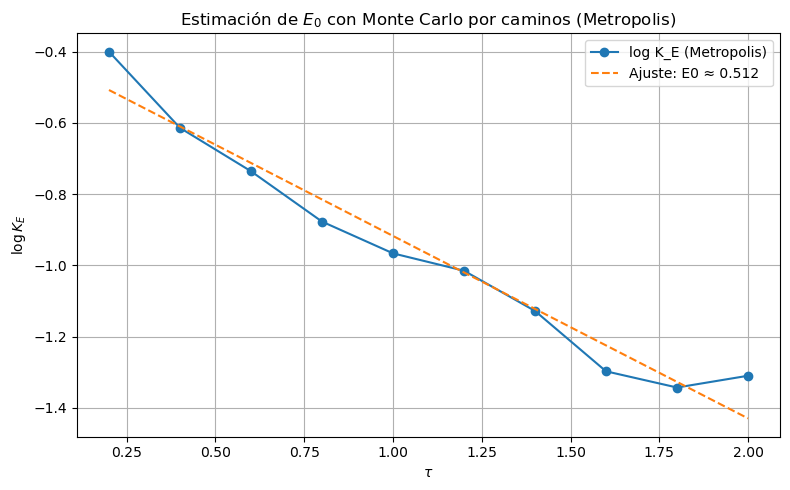

E0 estimado: 0.5121
E0 exacto:   0.5000
Error relativo: 2.42%


In [10]:
# Graficando el ajuste
plt.figure(figsize=(8, 5))

plt.plot(tau_values, log_K, 'o-', label='log K_E (Metropolis)')
plt.plot(tau_values, intercept - E0_est * tau_values, '--', label=f'Ajuste: E0 ≈ {E0_est:.3f}')

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\log K_E$")
plt.title("Estimación de $E_0$ con Monte Carlo por caminos (Metropolis)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Resultados
print(f"E0 estimado: {E0_est:.4f}")
print(f"E0 exacto:   {E0_exact:.4f}")
print(f"Error relativo: {abs(E0_est - E0_exact) / E0_exact * 100:.2f}%")

In [11]:
'''
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib as mpl
'''

'\nimport matplotlib.animation as animation\nfrom IPython.display import HTML\nimport matplotlib as mpl\n'

In [12]:
'''
M = 200   #Parametros del ultimo tau del oscilador
delta_tau = 2.0/500

# Seleccionar las primeras 100 trayectorias
paths_subset = np.array(paths)
taus = np.linspace(0, (paths_subset.shape[1] - 1) * delta_tau, paths_subset.shape[1])

# Crear figura y líneas
fig, ax = plt.subplots()
lines = [ax.plot([], [], lw=1.5, alpha=0.7)[0] for _ in range(len(paths_subset))]
ax.set_xlim(taus[0], taus[-1])
ax.set_ylim(np.min(paths_subset), np.max(paths_subset))
ax.set_xlabel(r'Tiempo imaginario $\tau$')
ax.set_ylabel(r'$x(\tau)$')
ax.set_title("Trayectorias desde $x_0$ hasta $x_f$")

# Inicialización
def init():
    for line in lines:
        line.set_data([], [])
    return lines

# Actualización
def update(frame):
    for i, line in enumerate(lines):
        line.set_data(taus[:frame + 1], paths_subset[i, :frame + 1])
    return lines

# Crear animación
mpl.rcParams['animation.embed_limit'] = 50 
ani = animation.FuncAnimation(
    fig, update, frames=paths_subset.shape[1],
    init_func=init, blit=True, interval=100
)

plt.close(fig)
HTML(ani.to_jshtml())
'''

'\nM = 200   #Parametros del ultimo tau del oscilador\ndelta_tau = 2.0/500\n\n# Seleccionar las primeras 100 trayectorias\npaths_subset = np.array(paths)\ntaus = np.linspace(0, (paths_subset.shape[1] - 1) * delta_tau, paths_subset.shape[1])\n\n# Crear figura y líneas\nfig, ax = plt.subplots()\nlines = [ax.plot([], [], lw=1.5, alpha=0.7)[0] for _ in range(len(paths_subset))]\nax.set_xlim(taus[0], taus[-1])\nax.set_ylim(np.min(paths_subset), np.max(paths_subset))\nax.set_xlabel(r\'Tiempo imaginario $\tau$\')\nax.set_ylabel(r\'$x(\tau)$\')\nax.set_title("Trayectorias desde $x_0$ hasta $x_f$")\n\n# Inicialización\ndef init():\n    for line in lines:\n        line.set_data([], [])\n    return lines\n\n# Actualización\ndef update(frame):\n    for i, line in enumerate(lines):\n        line.set_data(taus[:frame + 1], paths_subset[i, :frame + 1])\n    return lines\n\n# Crear animación\nmpl.rcParams[\'animation.embed_limit\'] = 50 \nani = animation.FuncAnimation(\n    fig, update, frames=paths_s

In [13]:
def pozo_inf(x, m, L=1.0):
    if x <= 0.0 or x >= L:
        return np.inf 
    return 0.0

In [14]:
tau_values = np.linspace(0.5, 2.0, 10)
log_K = []
for tau in tau_values:
    K, paths = propagador_MCMC(1.0, 0.5, 0.5, tau, 10000, 10000, 500, 0.1, pozo_inf)
    log_K.append(np.log(K))

slope, intercept, *_ = linregress(tau_values, log_K)
E0_est = -slope
E0_exact = (np.pi**2) / 2

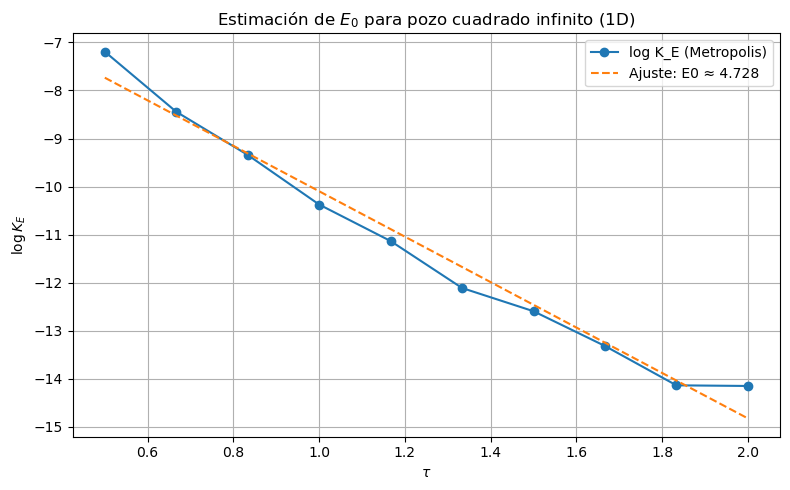

E0 estimado: 4.7284
E0 exacto:   4.9348
Error relativo: 4.18%


In [15]:
# Gráfico del resultado
plt.figure(figsize=(8, 5))
plt.plot(tau_values, log_K, 'o-', label='log K_E (Metropolis)')
plt.plot(tau_values, intercept - E0_est * np.array(tau_values), '--',
         label=f'Ajuste: E0 ≈ {E0_est:.3f}')
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\log K_E$")
plt.title("Estimación de $E_0$ para pozo cuadrado infinito (1D)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Resultados
print(f"E0 estimado: {E0_est:.4f}")
print(f"E0 exacto:   {E0_exact:.4f}")
print(f"Error relativo: {abs(E0_est - E0_exact) / E0_exact * 100:.2f}%")

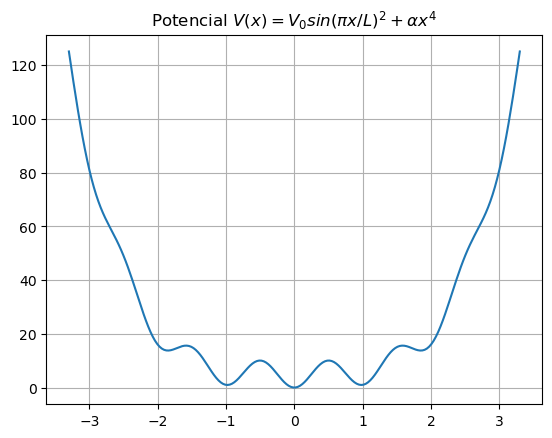

In [16]:
def pozo_calabera(x, m, L=1.0, alpha=1.0, V0 = 10.0):
    return V0 * np.sin(np.pi * x / L)**2 + alpha*x**4

x = np.linspace(-3.3, 3.3 , 200)
plt.plot(x, pozo_calabera(x, 1))
plt.title(r"Potencial $V(x) = V_0 sin( \pi x /L)^2 + \alpha x^4$")
plt.grid()
plt.show()

In [ ]:
tau_values = np.linspace(0.5, 2.0, 10)
log_K = []
for tau in tau_values:
    K, paths = propagador_MCMC(1.0, 0.5, 0.5, tau, 5000, 5000, 200, 0.1, pozo_calabera)
    log_K.append(np.log(K))

slope, intercept, *_ = linregress(tau_values, log_K)
E0_est = -slope
E0_df = 12.359163564778655

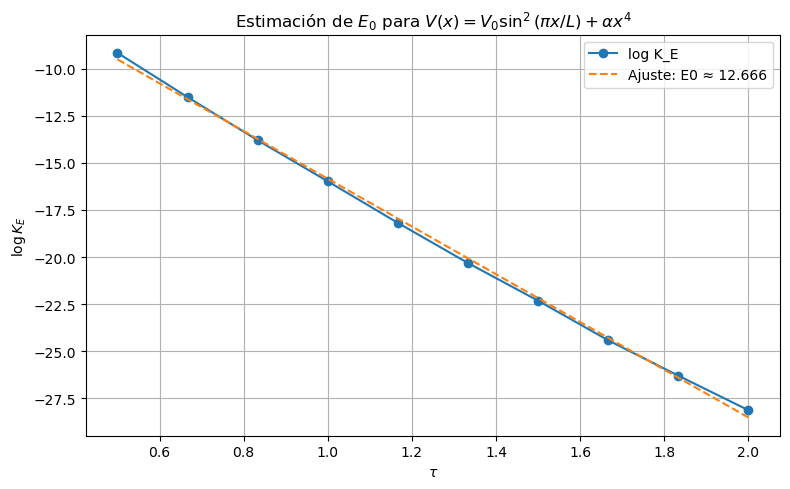

E0 estimado por MCMC: 12.6663
E0 estimado por metodo de diferencias finitas : 12.3592
Error relativo: 2.49%


In [24]:
# Gráfica
plt.figure(figsize=(8, 5))
plt.plot(tau_values, log_K, 'o-', label='log K_E')
plt.plot(tau_values, intercept - E0_est * np.array(tau_values), '--',
         label=f'Ajuste: E0 ≈ {E0_est:.3f}')
plt.xlabel(r"$\tau$")
plt.ylabel(r"$\log K_E$")
plt.title(r"Estimación de $E_0$ para $V(x) = V_0 \sin^2(\pi x/L) + \alpha x^4$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"E0 estimado por MCMC: {E0_est:.4f}")
print(f"E0 estimado por metodo de diferencias finitas : {E0_df:.4f}")
print(f"Error relativo: {abs(E0_est - E0_df) / E0_df * 100:.2f}%")

## Discusión y comentarios adicionales

- El método de Monte Carlo directo no es una opción: el costo computacional es alto y da malos resultados.  
- Es difícil generalizar esto a 3 dimensiones. Esto se debe a que la construcción de trayectorias significativas es mucho más compleja: en 3D no solo tienes una dirección, sino que ahora hay tres.  
- Este método es efectivo en 1D, pero recordemos que solo aplica a problemas donde la fase no es relevante. De lo contrario, se tiene que integrar de manera directa, como en [7], donde se usa el método de integración de doble exponencial.  
- Por otro lado, aunque este código es efectivo, aún tiene ciertos aspectos a mejorar: la aproximación de la acción S , el descarte de caminos, y la determinación manual de las variables `n`, `M`, `pasos_metropolis` y `delta`, que son dependientes entre sí.

## Conclusiones

- El código funciona correctamente para problemas en 1D que no dependan de la fase, como el cálculo de energías, incluso para potenciales exóticos como el de la "calavera".  
- El costo computacional sigue siendo alto.


## Referencias
[1]  Sakurai, J. J., & Napolitano, J. (2020). Modern Quantum Mechanics (3rd ed.). Cambridge University Press. \
[2] Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., ... & SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. Nature Methods, 17, 261–272.
Documentación de scipy.integrate.nquad: https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.nquad.html \
[3]  Ramos Segura, L. (2021). Métodos de Monte Carlo y sus aplicaciones (Trabajo Fin de Grado, Universidad de Almería).\
[4] Kalos, M. H., & Whitlock, P. A. (2008). Monte Carlo methods (2nd ed., revised and enlarged). Wiley-VCH. \
[5]  Das, A. (2019). Field Theory: A Path Integral Approach (3rd ed.). World Scientific Publishing. \
[6] Westbroek, M. J. E., King, P. R., Vvedensky, D. D., & Dürr, S. (2017). User’s guide to Monte Carlo methods for evaluating path integrals (arXiv:1712.08508). arXiv. https://arxiv.org/abs/1712.08508 \
[7] Rosenfelder, R. (2021). Evaluation of path integrals in real time (arXiv:2105.02880). arXiv. https://arxiv.org/abs/2105.02880
[8] Feynman, R. P., & Hibbs, A. R. (2010). Quantum Mechanics and Path Integrals (Emended ed., D. F. Styer, Ed.). Dover Publications. \